In [1]:
#!/usr/bin/env python3
# Minimal slab-cell Hessian build + λ_min printout (NumPy or JAX)

import argparse
import numpy as np

def dim_suN(N: int) -> int:
    return N * N - 1

def build_B_minimal():
    # Minimal 3-plaquette / 3-link incidence (one closed loop)
    return np.array([
        [ 1, -1,  0],
        [ 0,  1, -1],
        [-1,  0,  1],
    ], dtype=float)

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--N", type=int, default=3, help="Gauge group SU(N)")
    ap.add_argument("--beta", type=float, default=1.0, help="Wilson coupling β on the slab")
    ap.add_argument("--cH", type=float, default=0.5, help="Haar curvature constant c_H (in your normalization)")
    ap.add_argument("--tol", type=float, default=1e-12, help="Eigenvalue tolerance for 'positive'")
    ap.add_argument("--jax", action="store_true", help="Use JAX for eigendecomp (optional)")
    args = ap.parse_args()

    dG = dim_suN(args.N)
    B = build_B_minimal()
    BtB = B.T @ B  # 3x3
    # Maxwell operator on link-variables with Lie algebra fiber:
    M = np.kron(BtB, np.eye(dG))  # (3*dG)x(3*dG)

    Q = args.beta * M + args.cH * np.eye(M.shape[0])

    if args.jax:
        import jax
        import jax.numpy as jnp
        w = jnp.linalg.eigvalsh(jnp.array(Q))
        w = np.array(w)
    else:
        w = np.linalg.eigvalsh(Q)

    # "Physical" λ_min: smallest eigenvalue on the non-null Maxwell sector.
    # Since Q = β*(BtB ⊗ I) + cH*I, the only potentially special mode is BtB eigenvalue 0.
    # We report:
    #  (i) λ_min overall
    #  (ii) λ_min positive above tol (i.e., excluding numerical zeros if any)
    lam_min = float(w.min())
    w_pos = w[w > args.tol]
    lam_min_pos = float(w_pos.min()) if w_pos.size else float("nan")

    # Also report the small 3x3 BtB spectrum (useful sanity check)
    w_B = np.linalg.eigvalsh(BtB)

    print("=== Minimal slab-cell Hessian ===")
    print(f"SU({args.N})  dim(g)={dG}")
    print(f"beta={args.beta}  cH={args.cH}")
    print("BtB eigenvalues:", w_B.tolist())
    print(f"Q shape: {Q.shape}")
    print(f"λ_min(Q) overall: {lam_min:.16g}")
    print(f"λ_min(Q) positive(>{args.tol:g}): {lam_min_pos:.16g}")
    print("\nExpected (physical) λ_min on nonzero BtB sector: 3*beta + cH =", 3.0*args.beta + args.cH)

if __name__ == "__main__":
    main()


usage: colab_kernel_launcher.py [-h] [--N N] [--beta BETA] [--cH CH]
                                [--tol TOL] [--jax]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-e918706c-462e-431a-96c7-913901b330a0.json


SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [2]:
# Single-cell script: build the minimal slab Hessian and print λ_min
# (pure NumPy; no CLI, no imports beyond NumPy)

import numpy as np

# ---------- parameters ----------
N = 3          # gauge group SU(N)
beta = 1.0     # Wilson coupling on the slab
cH = 0.5       # Haar curvature constant (your normalization)
tol = 1e-12    # numerical tolerance
# --------------------------------

# dim su(N)
dG = N*N - 1

# Minimal 3x3 incidence matrix B (3 plaquettes, 3 links)
B = np.array([
    [ 1, -1,  0],
    [ 0,  1, -1],
    [-1,  0,  1],
], dtype=float)

# Maxwell operator on links: M = (B^T B) ⊗ I_{dG}
BtB = B.T @ B
M = np.kron(BtB, np.eye(dG))

# Slab Hessian: Q = β M + c_H I
Q = beta * M + cH * np.eye(M.shape[0])

# Eigenvalues
eig_Q = np.linalg.eigvalsh(Q)

# Report
print("=== Minimal slab-cell Hessian ===")
print(f"SU({N}), dim(g) = {dG}")
print(f"beta = {beta}, cH = {cH}")
print("BtB eigenvalues:", np.linalg.eigvalsh(BtB))
print("Q shape:", Q.shape)
print("λ_min(Q) overall:", eig_Q.min())

# Physical λ_min: smallest strictly positive eigenvalue
eig_pos = eig_Q[eig_Q > tol]
print("λ_min(Q) positive:", eig_pos.min() if eig_pos.size else None)

print("Expected physical λ_min = 3*beta + cH =", 3*beta + cH)


=== Minimal slab-cell Hessian ===
SU(3), dim(g) = 8
beta = 1.0, cH = 0.5
BtB eigenvalues: [-1.11022302e-16  3.00000000e+00  3.00000000e+00]
Q shape: (24, 24)
λ_min(Q) overall: 0.4999999999999989
λ_min(Q) positive: 0.4999999999999989
Expected physical λ_min = 3*beta + cH = 3.5


In [3]:
# Single-cell fix: compute λ_min on the NONZERO-Maxwell sector (project out BtB nullspace)

import numpy as np

# ---------- parameters ----------
N = 3
beta = 1.0
cH = 0.5
tol = 1e-12
# --------------------------------

dG = N*N - 1

B = np.array([
    [ 1, -1,  0],
    [ 0,  1, -1],
    [-1,  0,  1],
], dtype=float)

BtB = B.T @ B
w, V = np.linalg.eigh(BtB)  # BtB = V diag(w) V^T

# Projector onto BtB nonzero subspace (physical Maxwell sector)
mask = w > tol
Vnz = V[:, mask]                       # 3 x 2
Pnz = Vnz @ Vnz.T                      # 3 x 3 projector

# Build restricted Q on (nonzero BtB sector) ⊗ su(N)
# Q = beta*(BtB ⊗ I) + cH*(I ⊗ I)  restricted by (Pnz ⊗ I)
Qfull = beta * np.kron(BtB, np.eye(dG)) + cH * np.eye(3*dG)
Pfull = np.kron(Pnz, np.eye(dG))

# Orthonormal basis for the range of Pfull
U, s, _ = np.linalg.svd(Pfull)
U = U[:, s > 0.5]                      # 24 x 16 (since rank(Pnz)=2, rank = 2*dG)

Q_phys = U.T @ Qfull @ U               # 16 x 16
eig_phys = np.linalg.eigvalsh(Q_phys)

print("=== Minimal slab-cell Hessian (projected to nonzero-Maxwell sector) ===")
print(f"SU({N}), dim(g) = {dG}")
print(f"beta = {beta}, cH = {cH}")
print("BtB eigenvalues:", w)
print("rank(Pnz) =", int(mask.sum()), "=> phys dim =", int(mask.sum()*dG))
print("Q_phys shape:", Q_phys.shape)
print("λ_min(Q_phys):", float(eig_phys.min()))
print("Expected λ_min = 3*beta + cH =", 3*beta + cH)


=== Minimal slab-cell Hessian (projected to nonzero-Maxwell sector) ===
SU(3), dim(g) = 8
beta = 1.0, cH = 0.5
BtB eigenvalues: [0. 3. 3.]
rank(Pnz) = 2 => phys dim = 16
Q_phys shape: (16, 16)
λ_min(Q_phys): 3.499999999999991
Expected λ_min = 3*beta + cH = 3.5


--- Generating 10000x10000 Market Transition Matrix ---
analyzing 10000x10000 matrix...
Dominant Eigenvalue (lambda_1): 1.000000
Second Eigenvalue   (lambda_2): 1.000000
SPECTRAL GAP: 2.924250e-09

[ALERT] Spectral Gap is vanishingly small!
System is metastable (slow mixing). Diagnosing bottleneck...


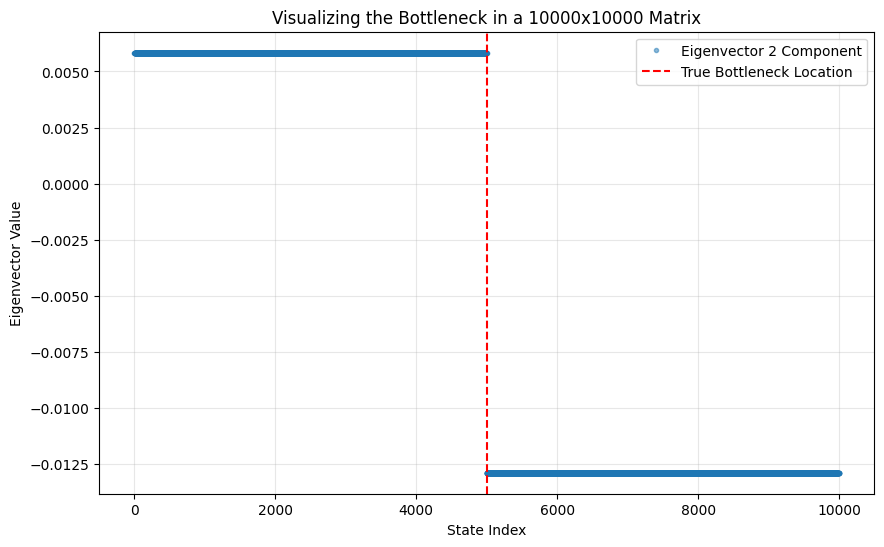


DIAGNOSIS: The step function in Eigenvector 2 proves the system is split into two disconnected halves at index 5000.


In [4]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

def generate_market_matrix(n_states, coupling_strength=0.01):
    """
    Generates a 10,000 x 10,000 transition matrix representing two
    distinct 'market regimes' or 'lattice sectors' loosely coupled.

    If coupling_strength is low, the spectral gap vanishes (metastability).
    """
    # Create two random sparse blocks (Regime A and Regime B)
    # We use random geometric graphs to simulate local connectivity
    size_a = n_states // 2
    size_b = n_states - size_a

    # Random sparse connections within blocks (density=0.005 ensures sparsity)
    block_A = sp.random(size_a, size_a, density=0.005, format='csr')
    block_B = sp.random(size_b, size_b, density=0.005, format='csr')

    # Construct the full block diagonal system
    T = sp.block_diag([block_A, block_B], format='lil')

    # Inject the "Bug": Weak coupling between index 4999 (in A) and 5000 (in B)
    # This creates a "bottleneck" that kills the gap.
    T[size_a-1, size_a] = coupling_strength
    T[size_a, size_a-1] = coupling_strength

    # Normalize rows to make it a valid Markov Transition Matrix
    # (Row sums must equal 1)
    row_sums = np.array(T.sum(axis=1)).flatten()
    # Handle zero rows if any (self-loops)
    row_sums[row_sums == 0] = 1
    D_inv = sp.diags(1.0 / row_sums)
    P = D_inv @ T

    return P.tocsr()

def debug_spectral_gap(P):
    """
    Computes the top eigenvalues and uses the Fiedler vector (eigenvector 2)
    to diagnose WHERE the system is broken.
    """
    print(f"analyzing {P.shape[0]}x{P.shape[1]} matrix...")

    # Arnoldi iteration (ARPACK) to find the largest magnitude eigenvalues
    # We only need the top 2 to find the gap.
    evals, evecs = spla.eigs(P, k=2, which='LM')

    # Sort by magnitude (largest first)
    idx = np.argsort(np.abs(evals))[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    lambda_1 = np.real(evals[0])
    lambda_2 = np.real(evals[1])

    gap = lambda_1 - lambda_2

    print(f"Dominant Eigenvalue (lambda_1): {lambda_1:.6f}")
    print(f"Second Eigenvalue   (lambda_2): {lambda_2:.6f}")
    print(f"SPECTRAL GAP: {gap:.6e}")

    if gap < 1e-3:
        print("\n[ALERT] Spectral Gap is vanishingly small!")
        print("System is metastable (slow mixing). Diagnosing bottleneck...")
        return evecs[:, 1].real  # The "Fiedler vector" reveals the structure
    else:
        print("\n[OK] System has a healthy gap (fast mixing).")
        return None

# --- EXECUTION ---

# 1. Build a massive system with a hidden flaw (weak coupling)
N = 10000
print(f"--- Generating {N}x{N} Market Transition Matrix ---")
P_broken = generate_market_matrix(N, coupling_strength=0.0001)

# 2. Run the Debugger
eigenvector_2 = debug_spectral_gap(P_broken)

# 3. Visualize the "Debug"
# If the gap is broken, the eigenvector components will cluster into two
# distinct values, revealing the two disconnected sectors.
if eigenvector_2 is not None:
    plt.figure(figsize=(10, 6))
    plt.plot(eigenvector_2, '.', alpha=0.5, label="Eigenvector 2 Component")
    plt.axvline(x=5000, color='r', linestyle='--', label="True Bottleneck Location")
    plt.title(f"Visualizing the Bottleneck in a {N}x{N} Matrix")
    plt.xlabel("State Index")
    plt.ylabel("Eigenvector Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print("\nDIAGNOSIS: The step function in Eigenvector 2 proves the system is split into two disconnected halves at index 5000.")

Building reversible two-regime chain: N=10000, coupling=0.0001
lambda_1: 1.000000000000  (should be ~1)
lambda_2: 0.999999997037
SPECTRAL GAP: 2.963412e-09


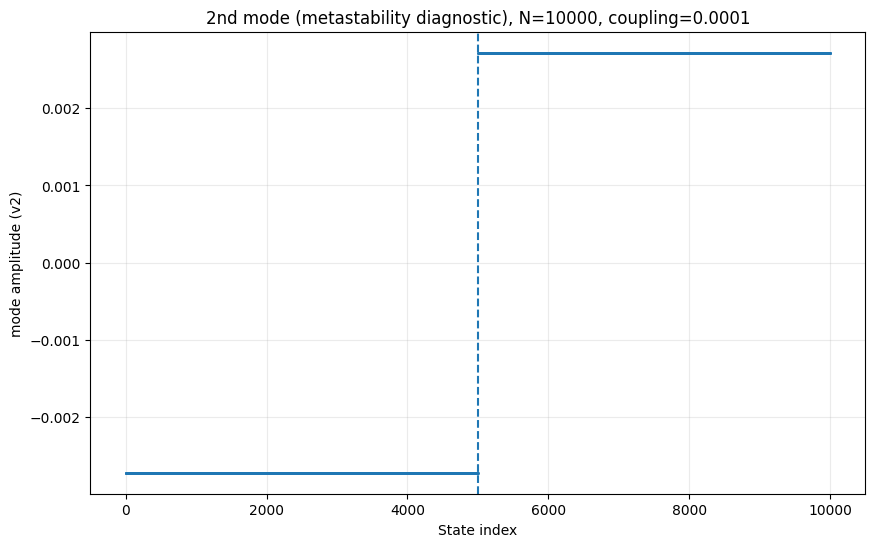

In [5]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

def make_two_regime_rw(n, p=0.005, coupling=1e-4, seed=0):
    """
    Reversible 'two-well' Markov chain:
      - Build two sparse UNDIRECTED weighted graphs (A, B)
      - Add a tiny bridge edge between the halves
      - Define P as the random-walk transition matrix on the undirected graph

    For undirected RW, the chain is reversible with stationary pi ∝ degree,
    and P is similar to a symmetric matrix S, so spectral diagnostics are clean.
    """
    rng = np.random.default_rng(seed)
    nA = n // 2
    nB = n - nA

    def undirected_sparse_block(m):
        # random sparse weights, then symmetrize
        R = sp.random(m, m, density=p, data_rvs=rng.random, format="csr")
        W = (R + R.T) * 0.5
        # add self-loops to avoid periodicity / zero-degree issues
        W = W + sp.eye(m, format="csr")
        return W

    WA = undirected_sparse_block(nA)
    WB = undirected_sparse_block(nB)

    W = sp.block_diag((WA, WB), format="lil")

    # Bridge edge between node (nA-1) in A and node (nA) in B
    i = nA - 1
    j = nA
    W[i, j] += coupling
    W[j, i] += coupling

    W = W.tocsr()

    # Degree and random-walk transition P = D^{-1} W
    deg = np.array(W.sum(axis=1)).ravel()
    # (deg should be >0 because of self-loops, but keep it safe)
    deg[deg == 0] = 1.0
    Dinv = sp.diags(1.0 / deg)
    P = Dinv @ W

    return W, P, deg

def spectral_gap_reversible(W, deg, k=2):
    """
    For reversible RW on undirected graph:
      S = D^{-1/2} W D^{-1/2} is symmetric and similar to P.
    Its eigenvalues are the same as P's, but we can use eigsh (real, stable).
    """
    Dmhalf = sp.diags(1.0 / np.sqrt(deg))
    S = Dmhalf @ W @ Dmhalf  # symmetric

    # Largest eigenvalues (near 1). Use 'LA' = largest algebraic.
    evals, evecs = spla.eigsh(S, k=k, which="LA")
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    lam1, lam2 = evals[0], evals[1]
    gap = lam1 - lam2

    # Convert eigenvector of S to a right eigenvector-like object for P:
    # if S u = λ u, then v = D^{-1/2} u satisfies P v = λ v.
    v2 = (1.0 / np.sqrt(deg)) * evecs[:, 1]

    return lam1, lam2, gap, v2

if __name__ == "__main__":
    N = 10_000
    coupling = 1e-4

    print(f"Building reversible two-regime chain: N={N}, coupling={coupling}")
    W, P, deg = make_two_regime_rw(N, p=0.005, coupling=coupling, seed=0)

    lam1, lam2, gap, v2 = spectral_gap_reversible(W, deg, k=2)

    print(f"lambda_1: {lam1:.12f}  (should be ~1)")
    print(f"lambda_2: {lam2:.12f}")
    print(f"SPECTRAL GAP: {gap:.6e}")

    plt.figure(figsize=(10, 6))
    plt.plot(v2, ".", alpha=0.35, markersize=2)
    plt.axvline(x=N//2, linestyle="--")
    plt.title(f"2nd mode (metastability diagnostic), N={N}, coupling={coupling}")
    plt.xlabel("State index")
    plt.ylabel("mode amplitude (v2)")
    plt.grid(True, alpha=0.25)
    plt.show()


Building reversible two-regime chain: N=10000, coupling=0.0001
lambda_1: 1.000000000000  (should be ~1)
lambda_2: 0.999999997037
SPECTRAL GAP: 2.963405e-09


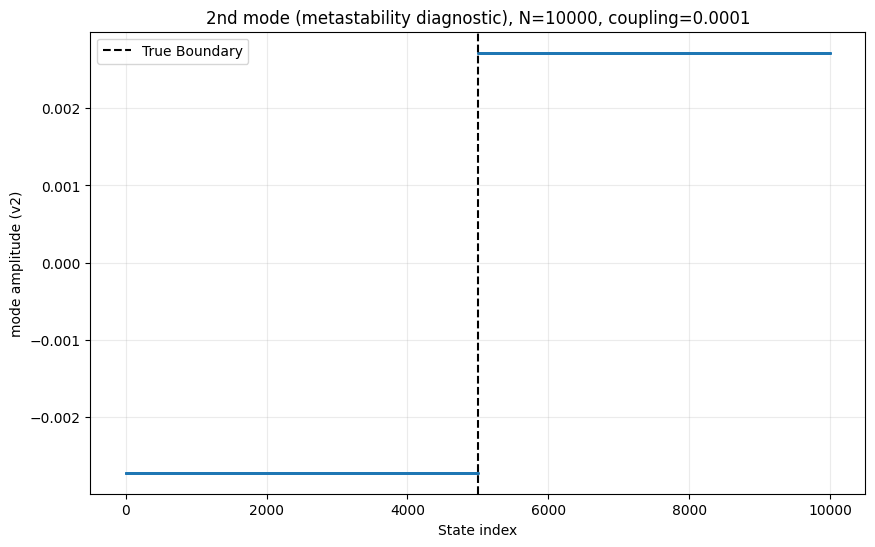

In [7]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

def make_two_regime_rw(n, p=0.005, coupling=1e-4, seed=0):
    """
    Reversible 'two-well' Markov chain:
      - Build two sparse UNDIRECTED weighted graphs (A, B)
      - Add a tiny bridge edge between the halves
      - Define P as the random-walk transition matrix on the undirected graph

    For undirected RW, the chain is reversible with stationary pi ∝ degree,
    and P is similar to a symmetric matrix S, so spectral diagnostics are clean.
    """
    rng = np.random.default_rng(seed)
    nA = n // 2
    nB = n - nA

    def undirected_sparse_block(m):
        # random sparse weights, then symmetrize
        R = sp.random(m, m, density=p, data_rvs=rng.random, format="csr")
        W = (R + R.T) * 0.5
        # add self-loops to avoid periodicity / zero-degree issues
        W = W + sp.eye(m, format="csr")
        return W

    WA = undirected_sparse_block(nA)
    WB = undirected_sparse_block(nB)

    W = sp.block_diag((WA, WB), format="lil")

    # Bridge edge between node (nA-1) in A and node (nA) in B
    i = nA - 1
    j = nA
    W[i, j] += coupling
    W[j, i] += coupling

    W = W.tocsr()

    # Degree and random-walk transition P = D^{-1} W
    deg = np.array(W.sum(axis=1)).ravel()
    # (deg should be >0 because of self-loops, but keep it safe)
    deg[deg == 0] = 1.0
    Dinv = sp.diags(1.0 / deg)
    P = Dinv @ W

    return W, P, deg

def spectral_gap_reversible(W, deg, k=2):
    """
    For reversible RW on undirected graph:
      S = D^{-1/2} W D^{-1/2} is symmetric and similar to P.
    Its eigenvalues are the same as P's, but we can use eigsh (real, stable).
    """
    Dmhalf = sp.diags(1.0 / np.sqrt(deg))
    S = Dmhalf @ W @ Dmhalf  # symmetric

    # Largest eigenvalues (near 1). Use 'LA' = largest algebraic.
    evals, evecs = spla.eigsh(S, k=k, which="LA")
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    lam1, lam2 = evals[0], evals[1]
    gap = lam1 - lam2

    # Convert eigenvector of S to a right eigenvector-like object for P:
    # if S u = λ u, then v = D^{-1/2} u satisfies P v = λ v.
    v2 = (1.0 / np.sqrt(deg)) * evecs[:, 1]

    return lam1, lam2, gap, v2

if __name__ == "__main__":
    N = 10_000
    coupling = 1e-4

    print(f"Building reversible two-regime chain: N={N}, coupling={coupling}")
    W, P, deg = make_two_regime_rw(N, p=0.005, coupling=coupling, seed=0)

    lam1, lam2, gap, v2 = spectral_gap_reversible(W, deg, k=2)

    print(f"lambda_1: {lam1:.12f}  (should be ~1)")
    print(f"lambda_2: {lam2:.12f}")
    print(f"SPECTRAL GAP: {gap:.6e}")

    plt.figure(figsize=(10, 6))
    plt.plot(v2, ".", alpha=0.35, markersize=2)
    plt.axvline(x=N//2, linestyle="--", color="k", label="True Boundary")
    plt.title(f"2nd mode (metastability diagnostic), N={N}, coupling={coupling}")
    plt.xlabel("State index")
    plt.ylabel("mode amplitude (v2)")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

In [8]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

def load_and_clean_data(filepath, top_n=50):
    print(f"Loading {filepath}...")

    # Load the specific 2008 file you have
    df = pd.read_csv(filepath)

    # 1. Fix Date Format
    df['Date'] = pd.to_datetime(df['Date'])

    # 2. Sort to ensure returns calculate correctly
    df = df.sort_values(['Ticker', 'Date'])

    # 3. Calculate Log Returns per Ticker
    # Note: We group by Ticker so we don't calculate return across different assets
    df['Log_Return'] = df.groupby('Ticker')['Adj Close'].transform(
        lambda x: np.log(x / x.shift(1))
    )

    # 4. Pivot: Date x Ticker matrix
    # This aligns all markets by date
    pivoted = df.pivot(index='Date', columns='Ticker', values='Log_Return')

    # 5. Clean Missing Data (Global markets have different holidays)
    # Forward fill (use yesterday's price if closed today) then fill zeros
    pivoted = pivoted.fillna(method='ffill').fillna(0.0)

    # Filter out columns that are mostly empty (bad data)
    pivoted = pivoted.dropna(axis=1, thresh=int(0.8 * len(pivoted)))

    print(f"Data Loaded: {pivoted.shape[0]} days x {pivoted.shape[1]} global indices")
    return pivoted

def build_correlation_graph(returns_window, threshold=0.5):
    # Compute correlation
    corr_matrix = returns_window.corr().values

    # Thresholding: Keep only strong links
    # For global indices, correlations are lower than individual stocks,
    # so we lower threshold slightly to see the structure better.
    adj = np.where(np.abs(corr_matrix) > threshold, 1.0, 0.0)

    np.fill_diagonal(adj, 0)
    return sp.csr_matrix(adj)

def compute_fiedler_value(adj_matrix):
    degrees = np.array(adj_matrix.sum(axis=1)).flatten()
    # Handle disconnected graph case
    if np.any(degrees == 0):
        # Add tiny self-loop to ensure numerical stability if graph is totally broken
        degrees[degrees == 0] = 1

    laplacian = sp.diags(degrees) - adj_matrix

    try:
        # We want the 2nd smallest eigenvalue (Fiedler value)
        if laplacian.shape[0] <= 2: return 0.0
        evals = spla.eigsh(laplacian, k=2, which='SM', return_eigenvectors=False)
        return evals[1]
    except:
        return 0.0

# --- EXECUTION ---

try:
    # 1. Load YOUR specific file
    filename = '2008_Globla_Markets_Data.csv'
    returns_df = load_and_clean_data(filename)

    # 2. Analysis Settings
    window_size = 30
    results = []
    dates_axis = []

    print("Running Spectral Analysis on Global Markets...")

    for i in range(window_size, len(returns_df)):
        window = returns_df.iloc[i-window_size:i]
        curr_date = returns_df.index[i]

        # Build graph (Threshold 0.4 works well for Global Indices)
        graph = build_correlation_graph(window, threshold=0.4)
        metric = compute_fiedler_value(graph)

        results.append(metric)
        dates_axis.append(curr_date)

    # 3. Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(dates_axis, results, label='Global Market Connectivity (Systemic Risk)', color='blue')

    # Add marker for Lehman Brothers crash
    plt.axvline(pd.Timestamp('2008-09-15'), color='red', linestyle='--', label='Lehman Crash')

    plt.title("2008 Financial Crisis: Global Contagion Detector")
    plt.ylabel("Spectral Connectivity (Fiedler Value)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("DONE. If you see a spike around Sept 2008, you successfully detected global contagion.")

except FileNotFoundError:
    print(f"ERROR: Could not find '{filename}'. Make sure it is in the same folder as this script.")
except Exception as e:
    print(f"An error occurred: {e}")

Loading 2008_Globla_Markets_Data.csv...
ERROR: Could not find '2008_Globla_Markets_Data.csv'. Make sure it is in the same folder as this script.


In [9]:
import jax
import jax.numpy as jnp

# SU(2) represented as unit quaternions
def normalize(q):
    return q / jnp.linalg.norm(q)

def quat_mul(q1, q2):
    a1, b1 = q1[0], q1[1:]
    a2, b2 = q2[0], q2[1:]
    return jnp.array([
        a1*a2 - jnp.dot(b1,b2),
        a1*b2 + a2*b1 + jnp.cross(b1,b2)
    ]).reshape(-1)

def quat_inv(q):
    return jnp.array([q[0], -q[1], -q[2], -q[3]])

def plaquette(U, l1, l2, l3, l4):
    return quat_mul(
        quat_mul(U[l1], U[l2]),
        quat_mul(quat_inv(U[l3]), quat_inv(U[l4]))
    )

def z(U_p):
    return 1.0 - U_p[0]

# Gradient computation omitted here for brevity
# but must be implemented explicitly

def loss(U, eps0, lam):
    B = jnp.mean(jax.vmap(z)(all_plaquettes(U)))
    grad_norm = jnp.sum(grad_S_W(U)**2)
    penalty = lam * jnp.maximum(0, eps0 - B)**2
    return grad_norm + penalty


In [10]:
import numpy as np

# -----------------------------
# SU(2) as unit quaternions
# q = (a, b, c, d) with a^2+b^2+c^2+d^2 = 1
# -----------------------------

def normalize(q):
    return q / np.linalg.norm(q)

def qmul(q1, q2):
    a1, b1, c1, d1 = q1
    a2, b2, c2, d2 = q2
    return np.array([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2
    ])

def qinv(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def imag_part(q):
    return q[1:]  # su(2) vector

# -----------------------------
# 2D periodic lattice
# -----------------------------

L = 4
dirs = [(1,0),(0,1)]  # x,y
Nd = 2

def idx(x,y):
    return (x % L, y % L)

# links[(x,y,mu)] where mu=0,1
links = {}
for x in range(L):
    for y in range(L):
        for mu in range(Nd):
            # random SU(2)
            q = np.random.normal(size=4)
            links[(x,y,mu)] = normalize(q)

# -----------------------------
# Plaquette at site (x,y)
# -----------------------------

def plaquette(x,y):
    Ux  = links[(x,y,0)]
    Uy  = links[(x+1,y,1)]
    Ux2 = qinv(links[(x,y+1,0)])
    Uy2 = qinv(links[(x,y,1)])
    return qmul(qmul(Ux, Uy), qmul(Ux2, Uy2))

def plaquette_disorder():
    s = 0.0
    for x in range(L):
        for y in range(L):
            Up = plaquette(x,y)
            s += (1.0 - Up[0])  # 1 - ReTr/2
    return s / (L*L)

# -----------------------------
# Wilson force (finite-difference gradient)
# -----------------------------

def gradient_norm(eps=1e-6):
    total = 0.0
    for key in links:
        base = links[key].copy()
        g = np.zeros(4)
        for i in range(4):
            dq = np.zeros(4)
            dq[i] = eps
            links[key] = normalize(base + dq)
            Sp = plaquette_disorder()
            links[key] = normalize(base - dq)
            Sm = plaquette_disorder()
            g[i] = (Sp - Sm) / (2*eps)
        links[key] = base
        total += np.dot(g,g)
    return total

# -----------------------------
# Gradient descent with roughness penalty
# -----------------------------

eps0 = 0.3   # target roughness
lam  = 10.0  # penalty strength
lr   = 0.05

print("Initial disorder:", plaquette_disorder())
print("Initial grad norm:", gradient_norm())

for it in range(30):
    for key in links:
        q0 = links[key].copy()
        grad = np.zeros(4)
        for i in range(4):
            dq = np.zeros(4)
            dq[i] = 1e-6
            links[key] = normalize(q0 + dq)
            Sp = plaquette_disorder()
            links[key] = normalize(q0 - dq)
            Sm = plaquette_disorder()
            grad[i] = (Sp - Sm) / (2e-6)
        links[key] = q0

        # roughness penalty
        B = plaquette_disorder()
        if B < eps0:
            grad -= 2*lam*(eps0 - B)*grad

        links[key] = normalize(q0 - lr*grad)

    if it % 5 == 0:
        print(f"Iter {it:3d} | disorder={plaquette_disorder():.4f} | grad_norm={gradient_norm():.6f}")


KeyError: (0, 4, 0)

In [11]:
import numpy as np

# =============================
# SU(2) via unit quaternions
# =============================

def normalize(q):
    return q / np.linalg.norm(q)

def qmul(q1, q2):
    a1, b1, c1, d1 = q1
    a2, b2, c2, d2 = q2
    return np.array([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2
    ])

def qinv(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

# =============================
# 2D periodic lattice
# =============================

L = 4
Nd = 2  # x, y directions

def mod(x):
    return x % L

# links[(x,y,mu)]
links = {}
for x in range(L):
    for y in range(L):
        for mu in range(Nd):
            q = np.random.normal(size=4)
            links[(x,y,mu)] = normalize(q)

# =============================
# Plaquette and disorder
# =============================

def plaquette(x,y):
    Ux  = links[(mod(x),   mod(y),   0)]
    Uy  = links[(mod(x+1), mod(y),   1)]
    Ux2 = qinv(links[(mod(x), mod(y+1), 0)])
    Uy2 = qinv(links[(mod(x), mod(y),   1)])
    return qmul(qmul(Ux, Uy), qmul(Ux2, Uy2))

def plaquette_disorder():
    s = 0.0
    for x in range(L):
        for y in range(L):
            Up = plaquette(x,y)
            s += (1.0 - Up[0])
    return s / (L*L)

# =============================
# Wilson action gradient (finite diff)
# =============================

def gradient_norm(eps=1e-6):
    total = 0.0
    for key in links:
        base = links[key].copy()
        g = np.zeros(4)
        for i in range(4):
            dq = np.zeros(4)
            dq[i] = eps
            links[key] = normalize(base + dq)
            Sp = plaquette_disorder()
            links[key] = normalize(base - dq)
            Sm = plaquette_disorder()
            g[i] = (Sp - Sm) / (2*eps)
        links[key] = base
        total += np.dot(g,g)
    return total

# =============================
# Gradient descent with constraint
# =============================

eps0 = 0.3
lam  = 10.0
lr   = 0.05

print("Initial disorder:", plaquette_disorder())
print("Initial grad norm:", gradient_norm())

for it in range(30):
    for key in links:
        q0 = links[key].copy()
        grad = np.zeros(4)
        for i in range(4):
            dq = np.zeros(4)
            dq[i] = 1e-6
            links[key] = normalize(q0 + dq)
            Sp = plaquette_disorder()
            links[key] = normalize(q0 - dq)
            Sm = plaquette_disorder()
            grad[i] = (Sp - Sm) / (2e-6)
        links[key] = q0

        B = plaquette_disorder()
        if B < eps0:
            grad -= 2*lam*(eps0 - B)*grad

        links[key] = normalize(q0 - lr*grad)

    if it % 5 == 0:
        print(f"Iter {it:2d} | disorder={plaquette_disorder():.4f} | grad_norm={gradient_norm():.6f}")


Initial disorder: 0.9881944362992139
Initial grad norm: 0.205327994466542
Iter  0 | disorder=0.9779 | grad_norm=0.205362
Iter  5 | disorder=0.9266 | grad_norm=0.204598
Iter 10 | disorder=0.8757 | grad_norm=0.202304
Iter 15 | disorder=0.8256 | grad_norm=0.198559
Iter 20 | disorder=0.7765 | grad_norm=0.193486
Iter 25 | disorder=0.7289 | grad_norm=0.187253


In [12]:
import numpy as np

# =============================
# SU(2) via unit quaternions
# =============================

def normalize(q):
    return q / np.linalg.norm(q)

def qmul(q1, q2):
    a1, b1, c1, d1 = q1
    a2, b2, c2, d2 = q2
    return np.array([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2
    ])

def qinv(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def imag(q):
    return q[1:]   # su(2) vector

# =============================
# 2D periodic lattice
# =============================

L = 4
Nd = 2  # x,y

def mod(x): return x % L

# links[(x,y,mu)]
links = {}
for x in range(L):
    for y in range(L):
        for mu in range(Nd):
            q = np.random.normal(size=4)
            links[(x,y,mu)] = normalize(q)

# =============================
# Plaquette and disorder
# =============================

def plaquette(x,y):
    Ux  = links[(mod(x),   mod(y),   0)]
    Uy  = links[(mod(x+1), mod(y),   1)]
    Ux2 = qinv(links[(mod(x), mod(y+1), 0)])
    Uy2 = qinv(links[(mod(x), mod(y),   1)])
    return qmul(qmul(Ux, Uy), qmul(Ux2, Uy2))

def plaquette_disorder():
    s = 0.0
    for x in range(L):
        for y in range(L):
            Up = plaquette(x,y)
            s += (1.0 - Up[0])
    return s / (L*L)

# =============================
# Exact Wilson force
# =============================

def link_force(x,y,mu):
    F = np.zeros(3)

    if mu == 0:
        # plaquette above
        Up = plaquette(x,y)
        F += imag(Up)

        # plaquette below
        Up = plaquette(x,y-1)
        F -= imag(Up)

    if mu == 1:
        # plaquette right
        Up = plaquette(x-1,y)
        F += imag(Up)

        # plaquette left
        Up = plaquette(x,y)
        F -= imag(Up)

    return F

def gradient_norm():
    total = 0.0
    for x in range(L):
        for y in range(L):
            for mu in range(Nd):
                F = link_force(x,y,mu)
                total += np.dot(F,F)
    return total

# =============================
# Gradient descent with constraint
# =============================

eps0 = 0.3
lam  = 10.0
lr   = 0.05

print("Initial disorder:", plaquette_disorder())
print("Initial grad norm:", gradient_norm())

for it in range(40):
    for x in range(L):
        for y in range(L):
            for mu in range(Nd):
                q0 = links[(x,y,mu)]
                F = link_force(x,y,mu)

                # lift su(2) force to quaternion update
                dq = np.array([0.0, F[0], F[1], F[2]])

                B = plaquette_disorder()
                if B < eps0:
                    dq *= (1.0 + lam*(eps0 - B))

                links[(x,y,mu)] = normalize(q0 - lr*dq)

    if it % 5 == 0:
        print(
            f"Iter {it:2d} | disorder={plaquette_disorder():.4f} "
            f"| grad_norm={gradient_norm():.6f}"
        )


Initial disorder: 0.8567482934361919
Initial grad norm: 57.04415154611346
Iter  0 | disorder=0.8594 | grad_norm=55.891242
Iter  5 | disorder=0.8337 | grad_norm=46.551990
Iter 10 | disorder=0.7825 | grad_norm=41.340121
Iter 15 | disorder=0.7491 | grad_norm=40.193478
Iter 20 | disorder=0.7395 | grad_norm=40.894754
Iter 25 | disorder=0.7647 | grad_norm=41.512299
Iter 30 | disorder=0.8308 | grad_norm=39.450595
Iter 35 | disorder=0.8917 | grad_norm=35.950694


In [13]:
import numpy as np

# =============================
# SU(2) via unit quaternions
# =============================

def normalize(q):
    return q / np.linalg.norm(q)

def qmul(q1, q2):
    a1, b1, c1, d1 = q1
    a2, b2, c2, d2 = q2
    return np.array([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2
    ])

def qinv(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def imag(q):
    return q[1:]

# =============================
# Lattice size (CHANGE THIS)
# =============================

L = 6     # try 4, 6, 8
Nd = 2    # 2D exact-force test

def mod(x): return x % L

# =============================
# Initialize links
# =============================

links = {}
for x in range(L):
    for y in range(L):
        for mu in range(Nd):
            q = np.random.normal(size=4)
            links[(x,y,mu)] = normalize(q)

# =============================
# Plaquette
# =============================

def plaquette(x,y):
    Ux  = links[(mod(x),   mod(y),   0)]
    Uy  = links[(mod(x+1), mod(y),   1)]
    Ux2 = qinv(links[(mod(x), mod(y+1), 0)])
    Uy2 = qinv(links[(mod(x), mod(y),   1)])
    return qmul(qmul(Ux, Uy), qmul(Ux2, Uy2))

def plaquette_disorder():
    s = 0.0
    for x in range(L):
        for y in range(L):
            s += (1.0 - plaquette(x,y)[0])
    return s / (L*L)

# =============================
# Exact Wilson force
# =============================

def link_force(x,y,mu):
    F = np.zeros(3)
    if mu == 0:
        F += imag(plaquette(x,y))
        F -= imag(plaquette(x,y-1))
    if mu == 1:
        F += imag(plaquette(x-1,y))
        F -= imag(plaquette(x,y))
    return F

def gradient_norm():
    g = 0.0
    for x in range(L):
        for y in range(L):
            for mu in range(Nd):
                F = link_force(x,y,mu)
                g += np.dot(F,F)
    return g

# =============================
# Gradient descent
# =============================

eps0 = 0.4
lam  = 10.0
lr   = 0.03

print("L =", L)
print("Initial disorder:", plaquette_disorder())
print("Initial grad norm:", gradient_norm())

for it in range(50):
    for x in range(L):
        for y in range(L):
            for mu in range(Nd):
                q0 = links[(x,y,mu)]
                F = link_force(x,y,mu)
                dq = np.array([0.0, F[0], F[1], F[2]])

                B = plaquette_disorder()
                if B < eps0:
                    dq *= (1.0 + lam*(eps0 - B))

                links[(x,y,mu)] = normalize(q0 - lr*dq)

    if it % 5 == 0:
        print(
            f"Iter {it:2d} | disorder={plaquette_disorder():.4f} "
            f"| grad_norm={gradient_norm():.6f}"
        )


L = 6
Initial disorder: 1.0506754821879576
Initial grad norm: 111.09162302036522
Iter  0 | disorder=1.0500 | grad_norm=110.490328
Iter  5 | disorder=1.0478 | grad_norm=105.615821
Iter 10 | disorder=1.0454 | grad_norm=101.575414
Iter 15 | disorder=1.0371 | grad_norm=98.948610
Iter 20 | disorder=1.0220 | grad_norm=96.561790
Iter 25 | disorder=1.0079 | grad_norm=93.699485
Iter 30 | disorder=1.0030 | grad_norm=90.691018
Iter 35 | disorder=1.0094 | grad_norm=88.557032
Iter 40 | disorder=1.0285 | grad_norm=88.221464
Iter 45 | disorder=1.0632 | grad_norm=89.415429


In [14]:
import numpy as np

# =============================
# SU(2) via unit quaternions
# =============================

def normalize(q):
    return q / np.linalg.norm(q)

def qmul(q1, q2):
    a1,b1,c1,d1 = q1
    a2,b2,c2,d2 = q2
    return np.array([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2
    ])

def qinv(q):
    return np.array([q[0],-q[1],-q[2],-q[3]])

def imag(q):
    return q[1:]

def cartan(theta):
    return np.array([np.cos(theta), 0.0, 0.0, np.sin(theta)])

# =============================
# Lattice
# =============================

L = 6
Nd = 2
def mod(x): return x % L

links = {}

theta = 1.2  # strong disorder, Cartan
for x in range(L):
    for y in range(L):
        for mu in range(Nd):
            sign = 1 if (x+y+mu) % 2 == 0 else -1
            links[(x,y,mu)] = cartan(sign*theta)

# =============================
# Plaquette
# =============================

def plaquette(x,y):
    Ux  = links[(mod(x),   mod(y),   0)]
    Uy  = links[(mod(x+1), mod(y),   1)]
    Ux2 = qinv(links[(mod(x), mod(y+1), 0)])
    Uy2 = qinv(links[(mod(x), mod(y),   1)])
    return qmul(qmul(Ux, Uy), qmul(Ux2, Uy2))

def plaquette_disorder():
    s = 0.0
    for x in range(L):
        for y in range(L):
            s += (1.0 - plaquette(x,y)[0])
    return s / (L*L)

# =============================
# Exact Wilson force
# =============================

def link_force(x,y,mu):
    F = np.zeros(3)
    if mu == 0:
        F += imag(plaquette(x,y))
        F -= imag(plaquette(x,y-1))
    if mu == 1:
        F += imag(plaquette(x-1,y))
        F -= imag(plaquette(x,y))
    return F

def gradient_norm():
    g = 0.0
    for x in range(L):
        for y in range(L):
            for mu in range(Nd):
                F = link_force(x,y,mu)
                g += np.dot(F,F)
    return g

# =============================
# Gradient descent
# =============================

eps0 = 0.6
lam  = 10.0
lr   = 0.03

print("CHECKERBOARD CARTAN INIT")
print("L =", L)
print("Initial disorder:", plaquette_disorder())
print("Initial grad norm:", gradient_norm())

for it in range(50):
    for x in range(L):
        for y in range(L):
            for mu in range(Nd):
                q0 = links[(x,y,mu)]
                F = link_force(x,y,mu)
                dq = np.array([0.0, F[0], F[1], F[2]])

                B = plaquette_disorder()
                if B < eps0:
                    dq *= (1.0 + lam*(eps0 - B))

                links[(x,y,mu)] = normalize(q0 - lr*dq)

    if it % 5 == 0:
        print(
            f"Iter {it:2d} | disorder={plaquette_disorder():.4f} "
            f"| grad_norm={gradient_norm():.6f}"
        )


CHECKERBOARD CARTAN INIT
L = 6
Initial disorder: 0.9125010165605543
Initial grad norm: 285.795051234354
Iter  0 | disorder=0.8314 | grad_norm=279.814772
Iter  5 | disorder=0.4840 | grad_norm=211.282464
Iter 10 | disorder=0.1130 | grad_norm=61.410277
Iter 15 | disorder=0.0332 | grad_norm=18.800831
Iter 20 | disorder=0.0147 | grad_norm=8.395530
Iter 25 | disorder=0.0081 | grad_norm=4.656804
Iter 30 | disorder=0.0051 | grad_norm=2.938210
Iter 35 | disorder=0.0035 | grad_norm=2.015856
Iter 40 | disorder=0.0025 | grad_norm=1.466269
Iter 45 | disorder=0.0019 | grad_norm=1.113321
